In [11]:
import pandas as pd
import numpy as np


df = pd.read_csv("covid19_patient_symptoms_diagnosis.csv")

df_cleaned = df.copy()

# fill missing values in comorbidity
df_cleaned["comorbidity"] = df_cleaned["comorbidity"].fillna("None")

# symptom columns
symptoms = [
    "fever", "dry_cough", "sore_throat", "fatigue", "headache",
    "shortness_of_breath", "loss_of_smell", "loss_of_taste", "chest_pain"
]


In [12]:
print(df_cleaned.head())

   patient_id  age  gender  fever  dry_cough  sore_throat  fatigue  headache  \
0           1   52    Male      1          0            1        1         0   
1           2   15    Male      0          0            0        1         1   
2           3   72    Male      1          0            1        0         0   
3           4   61  Female      0          0            1        1         1   
4           5   21  Female      1          1            0        0         0   

   shortness_of_breath  loss_of_smell  loss_of_taste  oxygen_level  \
0                    0              0              0            98   
1                    0              0              0            85   
2                    1              0              1            99   
3                    0              1              1            86   
4                    1              0              1            90   

   body_temperature comorbidity  travel_history  contact_with_patient  \
0              37.1    Di

# SECTION 4: DATA MODELING

In this section, we build machine learning models to predict COVID-19 diagnosis.

We use patient age, symptom, clinical features:

- age
- fever
- dry_cough
- sore_throat
- fatigue
- headache
- shortness_of_breath
- loss_of_smell
- loss_of_taste
- chest_pain
- oxygen_level
- body_temperature

Two models are used:

1. Logistic Regression (baseline model)  
2. Random Forest (advanced model)

The target variable is:

- covid_result

In [13]:
# select features and target

features = ["age","oxygen_level","body_temperature","fever","dry_cough","sore_throat","fatigue","headache","shortness_of_breath","loss_of_smell","loss_of_taste","chest_pain"]

X = df_cleaned[features]
y = df_cleaned["covid_result"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (5000, 12)
Target shape: (5000,)


In [14]:
from sklearn.model_selection import train_test_split

# split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4000, 12)
Testing data: (1000, 12)


## Baseline Model: Logistic Regression

In [15]:
from sklearn.linear_model import LogisticRegression

# create and train logistic regression model
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

# make predictions
y_pred_log = log_model.predict(X_test)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [16]:
from sklearn.metrics import accuracy_score

# calculate accuracy
accuracy_log = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", round(accuracy_log, 3))

Logistic Regression Accuracy: 0.818


## Advanced Model: Random Forest

In [17]:
from sklearn.ensemble import RandomForestClassifier

# create and train random forest model
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

# make predictions
y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [18]:
# calculate accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(accuracy_rf, 3))

Random Forest Accuracy: 0.861


# Model Comparison

Logistic Regression Accuracy: 0.818  
Random Forest Accuracy: 0.861  

Both models performed well in predicting COVID-19 diagnosis.

Random Forest achieved higher accuracy than Logistic Regression, so it was the better-performing model on this dataset.

This suggests that patient symptoms, oxygen level, body temperature, and age are useful predictors of COVID-19 diagnosis.

In [19]:
from sklearn.metrics import confusion_matrix

# confusion matrix for Random Forest
cm = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix (Random Forest):")
print(cm)

Confusion Matrix (Random Forest):
[[457  48]
 [ 91 404]]


## Confusion Matrix Interpretation

The confusion matrix shows that the Random Forest model correctly classified most patients, with relatively few incorrect predictions.

This supports the higher accuracy achieved by the Random Forest model.

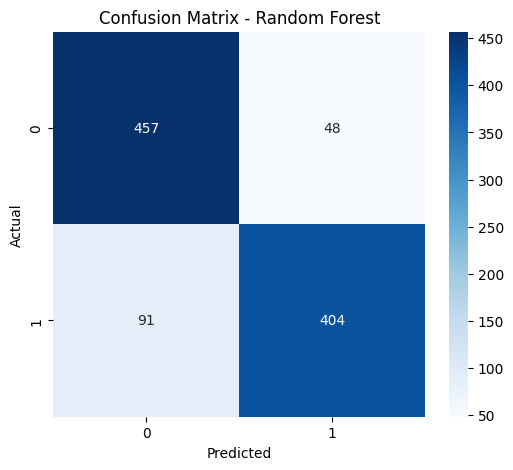

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()